## **ΥΠΟΛΟΓΙΣΤΙΚΗ ΕΡΓΑΣΙΑ IV: Χρονική εξέλιξη μιας κατάστασης σπιν $|s\rangle$ εντός σταθερού μαγνητικού πεδίου**

Θεωρήστε ένα κβαντικό σωματίδιο με αρχική κατάσταση σπιν $|s \rangle =\frac{1}{\sqrt{2}}\begin{bmatrix} 1 \\ 1\end{bmatrix}$ τη χρονική στιγμή $t=0$. Στο σωματίδιο εφαρμόζεται εξωτερικό σταθερό μαγνητικό πεδίο, παράλληλο προς τον άξονα z: $\vec{B}//\vec{e_z}$. Χρησιμοποιώντας τις δυνατότητες γραμμικής άλγεβρας της `SymPy`, ολοκληρώστε τις ακόλουθες ερωτήσεις.

**Παρατηρήσεις/Υποδείξεις:**

1. Ο γενικός τύπος του τελεστή χρονικής εξέλιξης για μια κατάσταση σπιν, όταν ένα εξωτερικό μαγνητικό πεδίο $\vec{B}$ εφαρμόζεται είναι: $$\hat{U}(t) = e^{-iωt(\vec{σ}\cdot \vec{B})}=cos(ωt)I_{2x2}-i (\vec{σ}\cdot \vec{n})sin(ωt)$$ όπου $I_{2x2}$ είναι ο $2x2$ ταυτοτικός πίνακας, $\vec{n}=\frac{\vec{B}}{|\vec{B}|}$ και $\vec{σ}=σ_1 \vec{e_x} + σ_2 \vec{e_y} + σ_3 \vec{e_z}$ (με $σ_i$, $i=1,2,3$ τους πίνακες *Pauli*).

2. Η μέση τιμή $\langle \hat{A} \rangle_ψ$ ενός ερμιτιανού τελεστή $\hat{A}$, ως προς μια κβαντική κατάσταση $|ψ\rangle$ είναι ίση με: $$\langle\hat{A} \rangle_ψ = \langle ψ|\hat{A}|ψ\rangle$$

3. Το διάνυσμα-τελεστής σπιν συνδέεται με το διάνυσμα-τελεστή των πινάκων Pauli μέσω της σχέσης:
$$\vec{s}=\frac{\hbar}{2}\vec{σ}$$

**Προετοιμασία**

In [1]:
# Φορτώνουμε τη βιβλιοθήκη SymPy
import sympy as smp

In [2]:
# Ορισμός χρήσιμων συμβόλων
t,omega,hbar = smp.symbols("t ω hbar",positive=True)
i = smp.I

# Ορίστε τους πίνακς Pauli και εκτυπώστε τους
sigma_1 = smp.Matrix([[0,1],[1,0]]) # στη θέση του 1 να αντικαταστήσετε την σωστή μορφή του πίνακα σ_1 = σ_x
sigma_2 = smp.Matrix([[0,-i],[i,0]]) # στη θέση του 2 να αντικαταστήσετε την σωστή μορφή του πίνακα σ_2 = σ_y
sigma_3 = smp.Matrix([[1,0],[0,-1]]) # στη θέση του 3 να αντικαταστήσετε την σωστή μορφή του πίνακα σ_3 = σ_z

display(sigma_1)
display(sigma_2)
display(sigma_3)

# Ορίστε τον ταυτοτικό πίνακα 2x2 και εκτυπώστε τον
iden_2x2 = smp.Matrix([[1,0],[0,1]]) # αντί για το 4 γράψτε την σωστή μορφή

display(iden_2x2)

# Ορίστε την αρχική κατάσταση-spin σε μορφή πίνακα και εκτυπώστε την
spin_init = (1/smp.sqrt(2)) * smp.Matrix([1,1]) # αντί για το 5 γράψτε την σωστή μορφή

display(spin_init)

Matrix([
[0, 1],
[1, 0]])

Matrix([
[0, -I],
[I,  0]])

Matrix([
[1,  0],
[0, -1]])

Matrix([
[1, 0],
[0, 1]])

Matrix([
[sqrt(2)/2],
[sqrt(2)/2]])

**Ερώτηση 1** 

Δείξτε ότι ο τελεστής της χρονικής εξέλιξης $\hat{U}(t)$ (της spin-κατάστασης του σωματιδίου) έχει την ακόλουθη μορφή μήτρας: 
$$\begin{bmatrix} e^{-iωt} & 0 \\ 0 & e^{iωt}\end{bmatrix} ή \begin{bmatrix} cos(ωt)-isin(ωt) & 0 \\ 0 & cos(ωt)+isin(ωt)\end{bmatrix}$$
Εξηγήστε στο παρακάτω **Markdown** κελί το σκεπτικό σας για να καταλήξετε στο συγκεκριμένο αποτέλεσμα.

**Εξήγηση**


Το μαγνητικό πεδίο $\vec{B} = (0, 0, B)$ είναι παράλληλο στον άξονα $z$, επομένως το $\vec{n} = \frac{B}{{|\vec{B}|}} = \frac{B}{B} = 1$, άρα τα εσωτερικά γινόμενα γίνονται:
$$
\vec{\sigma} \cdot \vec{B} = \sigma_3 \cdot B = \begin{bmatrix} B & 0 \\ 0 & -B \end{bmatrix}
$$

και

$$
\vec{\sigma} \cdot \vec{n} = 1 \cdot \sigma_3 = \begin{bmatrix} \cos{(\omega t)} & 0 \\ 0 & \cos{(\omega t)} \end{bmatrix} - \begin{bmatrix} i \sin{(\omega t)} & 0 \\ 0 & -i \sin{(\omega t)} \end{bmatrix} = \begin{bmatrix} \cos{(\omega t)} - i \sin{(\omega t)} & 0 \\ 0 & \cos{(\omega t)} + i \sin{(\omega t)} \end{bmatrix}
$$

In [3]:
# Ορισμός και εκτύπωση του τελεστή χρονικής εξέλιξης
def U(t,ω):
    return smp.simplify(smp.cos(omega*t)*iden_2x2 - i*(sigma_3)*smp.sin(omega*t))

# εντός της εντολής simplify γράψτε τον σωστό τύπο του τελεστή χρονικής εξέλιξης
# δοκιμάστε επίσης να επιστρέψετε την μορφή του τελεστή και χωρίς την εντολή simplify

def U_not_simpl(t,ω):
    return smp.cos(omega*t)*iden_2x2 - i*(sigma_3)*smp.sin(omega*t)

display(U(t,omega))
display(U_not_simpl(t,omega))

Matrix([
[exp(-I*t*ω),          0],
[          0, exp(I*t*ω)]])

Matrix([
[-I*sin(t*ω) + cos(t*ω),                     0],
[                     0, I*sin(t*ω) + cos(t*ω)]])

**Ερώτηση 2** 

**α)** Ορίστε μια συνάρτηση που επιστρέφει τη χρονική εξέλιξη της κατάστασης σπιν του σωματιδίου $|s(t)\rangle$ σε μορφή μήτρας και εμφανίστε τη συμβολική μορφή της $|s(t)\rangle$.

**Βοήθεια**

Για να λάβουμε την χρονική εξέλιξη $|s(t)\rangle$ της spin-κατάστασης ενός σωματιδίου, αρκεί να εφαρμόσουμε τον τελεστή $\hat{U}(t)$, πολλαπλασιάζοντας την αρχική spin-κατάσταση $|s\rangle$ από τα αριστερά. Δηλαδή:

$$|s(t)\rangle=\hat{U}(t)|s\rangle$$

In [4]:
# Ορισμός και εκτύπωση της χρονικής εξέλιξης της spin-κατάστασης
# του σωματιδίου

def spin_t(t,ω):
    return smp.simplify(U(t, omega) * spin_init)

# εντός της εντολής simplify γράψτε τον σωστό τύπο
# της χρονικής εξέλιξης της spin-κατάστασης

display(spin_t(t,omega))

Matrix([
[sqrt(2)*exp(-I*t*ω)/2],
[ sqrt(2)*exp(I*t*ω)/2]])

**β)** Βρείτε την μορφή της $|s(t)\rangle$ τη χρονική στιγμή $t=2s$, όταν $ω=\frac{π}{3}Hz$.

In [5]:
display(spin_t(2,omega).subs(omega,smp.pi/3)) #symvolikh timh
display(spin_t(2,omega).subs(omega,smp.pi/3).evalf(3)) #arithmitikh timh

Matrix([
[sqrt(2)*exp(-2*I*pi/3)/2],
[ sqrt(2)*exp(2*I*pi/3)/2]])

Matrix([
[-0.354 - 0.612*I],
[-0.354 + 0.612*I]])

**Ερώτηση 3** 

**α)** Βρείτε τη συμβολική μορφή των ακόλουθων μέσων τιμών: $\langle \hat{s}_x \rangle_t$, $\langle \hat{s}_y \rangle_t$ και $\langle \hat{s}_z \rangle_t$, ως προς την κατάσταση σπιν $|s(t)\rangle$. 

In [6]:
# Ορισμός και εκτύπωση των spin-πινάκων s_x,s_y και s_z
s_x = hbar/2 * sigma_1
s_y = hbar/2 * sigma_2
s_z = hbar/2 * sigma_3

# γράψτε παραπάνω τον σωστό τύπο των πινάκων s_x,s_y και s_z

display(s_x)
display(s_y)
display(s_z)

Matrix([
[     0, hbar/2],
[hbar/2,      0]])

Matrix([
[       0, -I*hbar/2],
[I*hbar/2,         0]])

Matrix([
[hbar/2,       0],
[     0, -hbar/2]])

In [7]:
# Εύρεση και εκτύπωση των ζητούμενων μέσων τιμών
mean_s_x = smp.simplify(spin_t(t, omega).H * s_x * spin_t(t, omega))[0] # <s_x>(t)
mean_s_y = smp.simplify(spin_t(t, omega).H * s_y * spin_t(t, omega))[0] # <s_y>(t)
mean_s_z = smp.simplify(spin_t(t, omega).H * s_z * spin_t(t, omega))[0] # <s_z>(t)

# εντός των εντολών simplify γράψτε τους σωστούς τύπους
# για τις ζητούμενες μέσες τιμές

display(mean_s_x)
display(mean_s_y)
display(mean_s_z)

hbar*cos(2*t*ω)/2

hbar*sin(2*t*ω)/2

0

**β)** Ορίστε τις μέσες τιμές $\langle \hat{s}_x \rangle_t$ και $\langle \hat{s}_y \rangle_t$ ως αριθμητικές συναρτήσεις των $t$ και $ω$, χρησιμοποιώντας την εντολή `lambdify()`. Θεωρείστε ότι $\hbar=1$, $ω=\frac{π}{4}Hz$ και δημιουργήστε ένα `NumPy` linspace 100 σημείων του $t$, στο διάστημα $[0,4]s$. Φτιάξτε μια γραφική παράσταση χρησιμοποιώντας τις τιμές της αριθμητικής συνάρτησης $\langle \hat{s}_x \rangle_t$ στα σημεία του linspace ως συντεταγμένες στον οριζόντιο άξονα και τις τιμές της αριθμητικής συνάρτησης $\langle \hat{s}_y \rangle_t$ στα σημεία του linspace ως συντεταγμένες στον κατακόρυφο άξονα. Σχολιάστε το αποτέλεσμα.

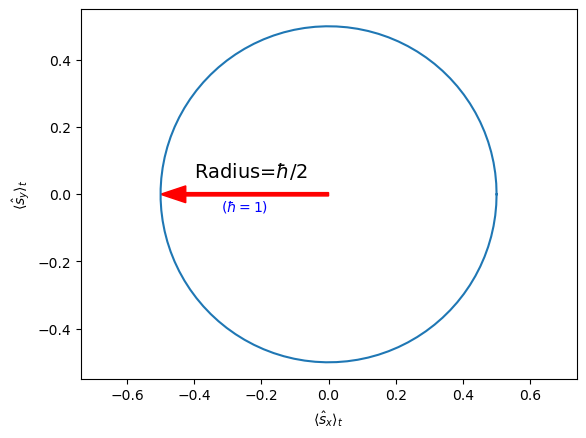

In [8]:
# αντί για 14 ή/και 15 να αντικαταστήσετε την σωστή παράσταση που θα
# μεταγλωττιστεί σε αριθμητική συνάρτηση
mean_s_x_num = smp.lambdify([t,omega],smp.cos(2*t*omega)/2,"numpy")
mean_s_y_num = smp.lambdify([t,omega],smp.sin(2*t*omega)/2,"numpy")

from numpy import linspace, pi # να εισάγετε μόνο την εντολή linspace και το pi από την NumPy
t_space = linspace(0,4,100) # φτιάξτε το ζητούμενο linspace

# εισαγωγή της βιβλιοθήκης matplotlib για γραφικές παραστάσεις
import matplotlib.pyplot as plt 

omega_val = pi/4 # αντικαταστήστε το 16 με τη δοσμένη τιμή για το ω

plt.plot(mean_s_x_num(t_space,omega_val),mean_s_y_num(t_space,omega_val))
plt.axis("equal") # δοκιμάστε να μετατρέψετε σε σχόλιο τη συγκεκριμένη εντολή και ξανατρέξτε το κελί, τι παρατηρείτε;
plt.xlabel(r"$\langle \hat{s}_x \rangle_t$")
plt.ylabel(r"$\langle \hat{s}_y \rangle_t$")
plt.text(-0.4, 0.05, 'Radius=$\hbar$/2', fontsize = 14)
plt.text(-0.25, -0.05, '($\hbar=1$)', fontsize = 10, color="blue",ha='center')
plt.arrow(0, 0, -0.5, 0, width=0.01, head_width=0.05, length_includes_head=True, color='red')
plt.show()

**Σχολιασμός αποτελέσματος**

Με τον κώδικα σχεδιάστηκε η μέση τιμή του spin στον x-άξονα η οποία είναι $\frac{1}{2} \cos{2t\omega}$ και στον y άξονα η μέση τιμή του spin-y, $\frac{1}{2} \sin{2t\omega}$, οι οποίες είναι παραμετρικές εξισώσεις ενός κύκλου με ακτίνα $\frac{1}{2}$, έτσι εξηγείται λοιπόν και ο κύκλος που παίρνουμε ως output. 